In [1]:
import re
import json
from PIL import Image

from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
)

/home/aleksandr/Рабочий стол/ai-catalog-parser/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "numind/NuExtract3"
image_path = "../data/pages/2026箭牌卫浴产品-5-9_page_2.png"

In [3]:
image = Image.open(image_path)
height, width = image.size

In [4]:
model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    device_map="auto",
)
processor = AutoProcessor.from_pretrained(
    model_name
)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 723/723 [00:00<00:00, 845.73it/s] 


In [5]:
schema = {
    "products": [
        {
            "name": "string",
            "description": ["string"],
            "product_center": {
                "x": "number",
                "y": "number",
            },
            "price": {
                "value": "number",
                "currency": "currency",
            },
            "specifications": {
                "dimensions": {
                    "length": "number",
                    "width": "number",
                    "height": "number",
                    "unit": "string",
                },
                "weight": {
                    "value": "number",
                    "unit": "string"
                },

                "other": ["string"],
            },
            "sku": "string",
        },
    ],
}

prompt = f"""
Extract all products from the catalog page.

Return ONLY valid JSON matching the schema.

Each product_center MUST satisfy:
- normalized coordinates in range [0.0, 1.0]
- x and y represent the center of the main product photo ONLY
- coordinates are relative to full page width and height
- (0,0) is top-left, (1,1) is bottom-right
- values MUST NOT exceed [0,1] under any circumstance

If no products exist, return: {{"products": []}}

Schema:
{json.dumps(schema, indent=2)}
"""

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {
                "type": "text",
                "text": f"{prompt}",
            },
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)

inputs = processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs, 
    max_new_tokens=2048,
)
generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(
        inputs.input_ids,
        generated_ids
    )
]

output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]
output_text = re.sub(r'.*?</think>', '', output_text, flags=re.DOTALL).strip()

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


In [6]:
result = json.loads(output_text)
print(json.dumps(result, indent=4, ensure_ascii=False))

{
    "products": [
        {
            "name": "AD810 智能坐便器",
            "description": [
                "基础功能：①侧边按键 ②座圈加热 ③离座冲水 ④温馨氛围灯 ⑤妇洗便洗 ⑥烘干除臭 ⑦感应润瓷 ⑧感应翻盖 ⑨脚触翻盖翻圈",
                "双泵冲水系统：通过离心泵加压助推，配合虹吸管道负压效果，带来强劲的冲水效果，采用陶瓷一体下沉式水箱，提前蓄水，冲吸双擎，无惧低压",
                "微波感应翻盖：靠近马桶0.8m，氛围灯亮起，便盖打开，智能交互，无需弯腰",
                "脚感翻盖翻圈：脚靠近电容感应器，进行翻盖/翻圈/合盖合圈冲水功能",
                "灵动智慧冲：自动识别男士小便场景和落座大小便场景，如厕更舒心，更省水"
            ],
            "product_center": {
                "x": 0.3,
                "y": 0.35
            },
            "price": {
                "value": 2760,
                "currency": "CNY"
            },
            "specifications": {
                "dimensions": {
                    "length": 712,
                    "width": 394,
                    "height": 456,
                    "unit": "mm"
                },
                "weight": {
                    "value": null,
                    "unit": null
                },
                "other": [
 

In [4]:
from paddleocr import PaddleOCRVL

layout_detector = PaddleOCRVL(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
)

/home/aleksandr/Рабочий стол/ai-catalog-parser/.paddle_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aleksandr/Рабочий стол/ai-catalog-parser/.paddle_venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-DocLayoutV3', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/aleksandr/.paddlex/official_models/PP-DocLayoutV3`.
Creating model: ('PaddleOCR-VL-1.5-0.9B', None, None)
Model files already exist. Using cached files. To redownload, please delet

In [5]:
layout_detector_output = layout_detector.predict(image_path)

images_bboxes = [
    bbox['coordinate']
    for bbox in layout_detector_output[0]['layout_det_res']['boxes']
    if bbox['label'] == 'image'
]

/home/aleksandr/Рабочий стол/ai-catalog-parser/.paddle_venv/lib/python3.12/site-packages/paddle/tensor/creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(


In [6]:
images_bboxes

[[660, 425, 1417, 1033],
 [1571, 305, 1770, 506],
 [413, 1592, 1003, 2018],
 [1146, 1623, 1689, 1964],
 [3109, 632, 3567, 1209]]

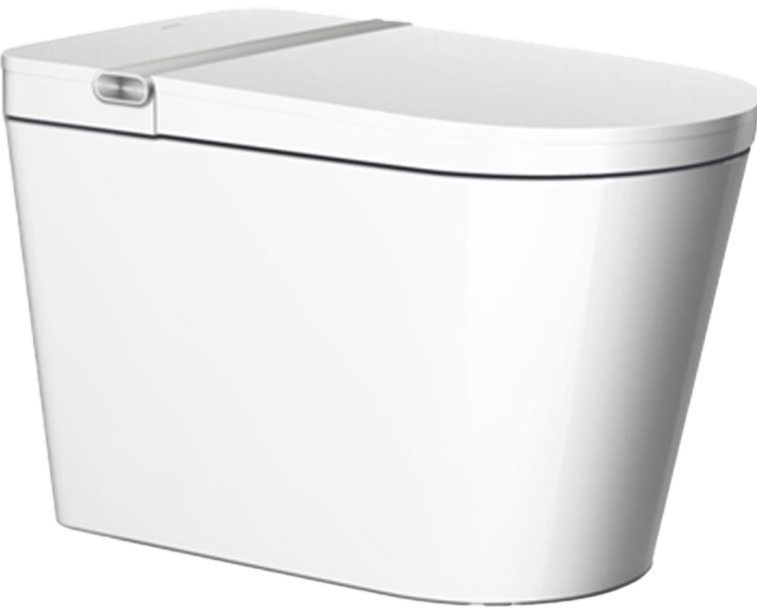

In [7]:
import math

x, y = 0.3, 0.35

best_bbox = None
min_dist = float("inf")

for bbox in images_bboxes:
    x0, y0, x1, y1 = bbox

    center = (
        (x1 - x0) / 2, 
        (y1 - y0) / 2
    )
    vlm_center = (
        x * width,
        y * height
    )

    dist = math.sqrt(
        (vlm_center[0] - center[0]) ** 2 + 
        (vlm_center[1] - center[1]) ** 2
    )
    if dist < min_dist:
        min_dist = dist
        best_bbox = bbox

cropped = image.crop(best_bbox)
cropped